# GNN 기반 사기 리뷰 탐지 — [1] 데이터 전처리

**데이터셋**: YelpZip
**목표**: 그래프 신경망(GNN)을 이용한 조직적 사기 리뷰 탐지
**평가지표**: PR-AUC, Macro F1

---
## 노트북 구성
| 섹션 | 내용 |
|------|------|
| 1 | 데이터 로드 및 라벨 전처리 |
| 2 | 데이터 샘플링 (밀도 중심 및 유저 타겟팅) |
| 3 | 탐색적 데이터 분석 — 버스트 패턴 분석 |
| 4 | GNN 파이프라인 (샘플링 → 피처 → 엣지 → 학습 → 평가) |
| 5 | 버스트 피처 적용 전/후 성능 비교 실험 |

## 1. 데이터 로드 및 라벨 전처리

원본 YelpZip의 라벨은 `-1`(사기), `1`(정상)이므로
프로젝트 규칙에 따라 **`1`(사기) / `0`(정상)** 으로 변환합니다.

In [5]:
import pandas as pd
import os

# 데이터 로드 (Parquet 우선 로드, 없으면 CSV 로드 후 변환)
if os.path.exists("yelpzip.parquet"):
    print("Loading from yelpzip.parquet...")
    df = pd.read_parquet("yelpzip.parquet")
else:
    print("Reading yelpzip.csv and converting to Parquet...")
    df = pd.read_csv("yelpzip.csv", index_col=0)
    df.to_parquet("yelpzip.parquet")

print("=== 현재 라벨 분포 확인 ===")
print(df["label"].value_counts())
print(f"전체 행 수: {len(df)}")

Loading from yelpzip.parquet...
=== 현재 라벨 분포 확인 ===
label
0    528019
1     80439
Name: count, dtype: int64
전체 행 수: 608458


In [6]:
# 원본 라벨 상태에 따라 변환 적용
unique_labels = set(df["label"].dropna().unique())

if unique_labels == {-1, 1}:
    # 원본 상태: -1(사기) → 1, 1(정상) → 0
    df["label"] = df["label"].map({-1: 1, 1: 0})
    print("원본(-1/1) → 변환 적용(1/0)")
elif unique_labels == {0, 1} or unique_labels == {0.0, 1.0}:
    # 이미 변환된 상태: 그대로 사용
    df["label"] = df["label"].astype(int)
    print("이미 변환된 상태(0/1) → 변환 없이 그대로 저장")
else:
    raise ValueError(f"예상치 못한 라벨 값: {unique_labels}")

print("\n=== 최종 라벨 분포 ===")
print(df["label"].value_counts())
print(f"사기 리뷰(1): {(df['label'] == 1).sum():,}")
print(f"정상 리뷰(0): {(df['label'] == 0).sum():,}")

df.to_parquet("yelpzip_preprocessed.parquet")
print("\n저장 완료: yelpzip_preprocessed.parquet")

이미 변환된 상태(0/1) → 변환 없이 그대로 저장

=== 최종 라벨 분포 ===
label
0    528019
1     80439
Name: count, dtype: int64
사기 리뷰(1): 80,439
정상 리뷰(0): 528,019

저장 완료: yelpzip_preprocessed.parquet


## 1-1. 연도별 리뷰 수 분포 시각화

전체 YelpZip 데이터에서 연도별 리뷰 수를 확인하여 샘플링 구간(2013~2014년) 선택의 근거를 시각화합니다.

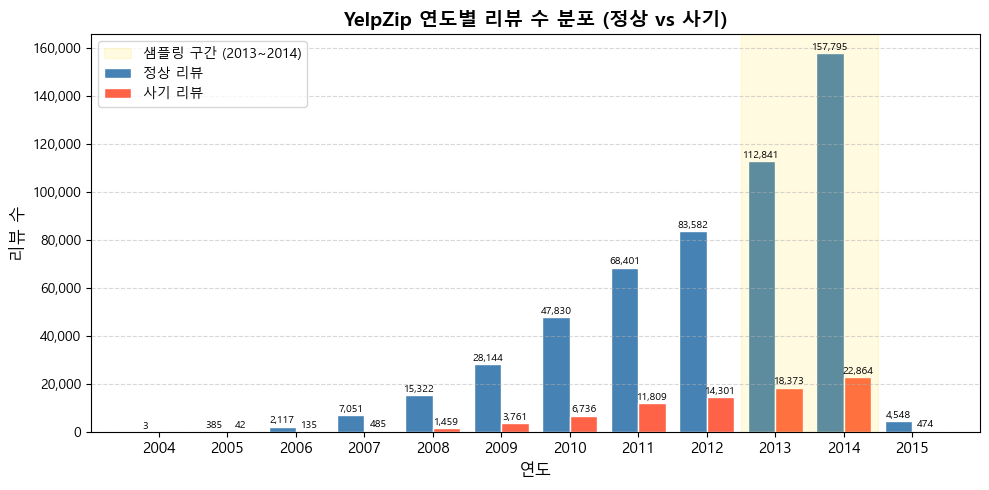


=== 연도별 집계 수치 ===
       정상(0)  사기(1)      전체  사기 비율(%)
year                                 
2004       3      0       3       0.0
2005     385     42     427       9.8
2006    2117    135    2252       6.0
2007    7051    485    7536       6.4
2008   15322   1459   16781       8.7
2009   28144   3761   31905      11.8
2010   47830   6736   54566      12.3
2011   68401  11809   80210      14.7
2012   83582  14301   97883      14.6
2013  112841  18373  131214      14.0
2014  157795  22864  180659      12.7
2015    4548    474    5022       9.4


In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm

# Windows 한글 폰트 설정 (맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 연도 컬럼 추출
df_plot = df.copy()
df_plot['year'] = pd.to_datetime(df_plot['date']).dt.year

# 연도별 정상/사기 리뷰 수 집계
year_counts = df_plot.groupby(['year', 'label']).size().unstack(fill_value=0)
year_counts.columns = ['정상(0)', '사기(1)']
year_counts = year_counts.sort_index()

# 바 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(year_counts))
bar_w = 0.4

bars_normal = ax.bar(
    [i - bar_w / 2 for i in x],
    year_counts['정상(0)'],
    width=bar_w,
    color='steelblue',
    label='정상 리뷰',
    edgecolor='white'
)
bars_fraud = ax.bar(
    [i + bar_w / 2 for i in x],
    year_counts['사기(1)'],
    width=bar_w,
    color='tomato',
    label='사기 리뷰',
    edgecolor='white'
)

# 샘플링 구간 강조 (2013~2014)
sampling_years = [year_counts.index.tolist().index(y) for y in [2013, 2014] if y in year_counts.index]
if sampling_years:
    ax.axvspan(
        min(sampling_years) - 0.5,
        max(sampling_years) + 0.5,
        alpha=0.12, color='gold', label='샘플링 구간 (2013~2014)'
    )

# 막대 위 숫자 표시
for bar in list(bars_normal) + list(bars_fraud):
    h = bar.get_height()
    if h > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 500,
            f'{h:,}',
            ha='center', va='bottom', fontsize=7.5
        )

ax.set_xticks(list(x))
ax.set_xticklabels(year_counts.index, fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.set_xlabel('연도', fontsize=12)
ax.set_ylabel('리뷰 수', fontsize=12)
ax.set_title('YelpZip 연도별 리뷰 수 분포 (정상 vs 사기)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('year_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== 연도별 집계 수치 ===")
year_counts['전체'] = year_counts['정상(0)'] + year_counts['사기(1)']
year_counts['사기 비율(%)'] = (year_counts['사기(1)'] / year_counts['전체'] * 100).round(1)
print(year_counts.to_string())

## 2. 데이터 샘플링 (GNN 연결성 및 도메인 지식 기반)

GNN 모델의 학습 효율과 연결 패턴 보존을 위해 단순 랜덤 샘플링 대신 **밀도 중심 및 유저 타겟팅 샘플링**을 수행합니다.

### 샘플링 전략
0. **시간적 배경**: 패턴의 일관성을 위해 데이터가 가장 집중된 **2013년~2014년** 리뷰만 사용합니다.
1. **공간적 배경 (대상 식당)**: 리뷰 수 상위 200개 식당으로 한정하여 데이터 밀도를 높입니다.
2. **사기 데이터 (사기 유저 타겟팅)**: 사기 리뷰를 한 번이라도 쓴 유저를 색출한 뒤, 그 유저가 쓴 '모든' 리뷰를 통째로 다 가져왔습니다. (위장 리뷰 패턴 파악 목적)
3. **정상 데이터 (헤비 유저 타겟팅)**: 리뷰를 3개 이상 작성한 '활성 유저(Active User)'의 데이터만 챙겼습니다. 네트워크 연결성을 확보하기 위함입니다.

In [8]:
print("=== 샘플링 시작 ===")

# 0. 시간 필터링 (2013-2014)
df['date'] = pd.to_datetime(df['date'])
df = df[df['date'].dt.year.isin([2013, 2014])].copy()
print(f"0. 2013-2014년 리뷰 수: {len(df):,}")

# 1. 상위 200개 식당 필터링
top_n_prods = 200
top_prods = df['prod_id'].value_counts().head(top_n_prods).index
df_filtered = df[df['prod_id'].isin(top_prods)].copy()
print(f"1. 상위 {top_n_prods}개 식당 리뷰 수: {len(df_filtered):,}")

# 2. 사기 유저 색출 및 해당 유저의 모든 리뷰 추출
fraud_users = df_filtered[df_filtered['label'] == 1]['user_id'].unique()
df_fraud = df_filtered[df_filtered['user_id'].isin(fraud_users)].copy()
print(f"2. 사기 유저({len(fraud_users):,})의 모든 리뷰 수: {len(df_fraud):,}")

# 3. 활성 정상 유저 (리뷰 3개 이상) 추출
active_normal_users = df_filtered[~df_filtered['user_id'].isin(fraud_users)] \
    .groupby('user_id').filter(lambda x: len(x) >= 3)['user_id'].unique()
df_normal = df_filtered[df_filtered['user_id'].isin(active_normal_users)].copy()
print(f"3. 활성 정상 유저({len(active_normal_users):,})의 리뷰 수: {len(df_normal):,}")

# 최종 샘플링 데이터 병합
df_sampled = pd.concat([df_fraud, df_normal]).drop_duplicates().reset_index(drop=True)

print("\n=== 샘플링 결과 ===")
print(f"최종 샘플링 행 수: {len(df_sampled):,}")
print(df_sampled['label'].value_counts())
print(f"사기 비율: {df_sampled['label'].mean()*100:.1f}%")

df_sampled.to_parquet("yelpzip_sampled.parquet")
df_sampled.to_csv("yelpzip_sampled.csv", index=False)
print("\n저장 완료: yelpzip_sampled.parquet / yelpzip_sampled.csv")

=== 샘플링 시작 ===
0. 2013-2014년 리뷰 수: 311,873
1. 상위 200개 식당 리뷰 수: 107,445
2. 사기 유저(10,108)의 모든 리뷰 수: 13,282
3. 활성 정상 유저(7,331)의 리뷰 수: 37,668

=== 샘플링 결과 ===
최종 샘플링 행 수: 50,950
label
0    38291
1    12659
Name: count, dtype: int64
사기 비율: 24.8%

저장 완료: yelpzip_sampled.parquet / yelpzip_sampled.csv
